In [239]:
import h5py
from pathlib import Path
import numpy as np
import random
import scipy
import matplotlib.pyplot as plt

import os

# Exploratory Data Analises


## 1. Load and test data

In [ ]:
path_to_file = Path('../data') / 'Halfmile3D_add_geom_sorted.hdf5'
print(dict(h5py.File(path_to_file)['TRACE_DATA/DEFAULT']))

data_dict = dict(h5py.File(path_to_file)['TRACE_DATA/DEFAULT'])

In [241]:
for k in data_dict.keys():
    print(k, '\t', data_dict[k].shape)

ALIAS_FREQ 	 (1099559, 1)
ALIAS_SLOPE 	 (1099559, 1)
AZIMUTH 	 (1099559, 1)
CDP 	 (1099559, 1)
CDPTRACE 	 (1099559, 1)
CDP_X 	 (1099559, 1)
CDP_Y 	 (1099559, 1)
CHANNEL 	 (1099559, 1)
COORD_SCALE 	 (1099559, 1)
COORD_UNIT 	 (1099559, 1)
CORR 	 (1099559, 1)
CROSSLINE 	 (1099559, 1)
DATA_START 	 (1099559, 1)
DATA_STOP 	 (1099559, 1)
DAY 	 (1099559, 1)
DELAY 	 (1099559, 1)
FIRST_BREAK_TIME 	 (1099559, 1)
FTRACE 	 (1099559, 1)
GAIN_TYPE 	 (1099559, 1)
GAP_SIZE 	 (1099559, 1)
HIGH_CUT_FREQ 	 (1099559, 1)
HIGH_CUT_SLOPE 	 (1099559, 1)
HORI_SUM 	 (1099559, 1)
HOUR 	 (1099559, 1)
HT_SCALE 	 (1099559, 1)
INLINE 	 (1099559, 1)
INSTR_GAIN_CONSTANT 	 (1099559, 1)
INSTR_INIT_GAIN 	 (1099559, 1)
INTERNAL_SORT1 	 (1099559, 1)
INTERNAL_SORT2 	 (1099559, 1)
LAG_TIME_A 	 (1099559, 1)
LAG_TIME_B 	 (1099559, 1)
LASTTR 	 (1099559, 1)
LINE 	 (1099559, 1)
LOW_CUT_FREQ 	 (1099559, 1)
LOW_CUT_SLOPE 	 (1099559, 1)
MINUTE 	 (1099559, 1)
MODELLED_BREAK_TIME 	 (1099559, 1)
NOTCH_FREQ 	 (1099559, 1)
NOTCH_SLOPE 	 (

In [242]:
valid_keys = [
    # 'data_array',
    'SHOTID',
    'SHOT_PEG',
    'SOURCE_X',
    'SOURCE_Y',
    'SOURCE_HT',
    'REC_PEG',
    'REC_X',
    'REC_Y',
    'REC_HT',
    'SAMP_RATE',
    'COORD_SCALE',
    'HT_SCALE',
    'SAMP_NUM',
    'SPARE1'
]
for k in valid_keys:
    print(
        k,
        '\t',
        data_dict[k].shape,
        '\t',
        np.unique(data_dict[k]).shape,
        '\t',
        data_dict[k][:2]
    )

SHOTID 	 (1099559, 1) 	 (690,) 	 [[20021449]
 [20021449]]
SHOT_PEG 	 (1099559, 1) 	 (690,) 	 [[20021449]
 [20021449]]
SOURCE_X 	 (1099559, 1) 	 (660,) 	 [[704570]
 [704570]]
SOURCE_Y 	 (1099559, 1) 	 (673,) 	 [[5243576]
 [5243576]]
SOURCE_HT 	 (1099559, 1) 	 (586,) 	 [[4541000]
 [4541000]]
REC_PEG 	 (1099559, 1) 	 (2378,) 	 [[10013085]
 [10013086]]
REC_X 	 (1099559, 1) 	 (1970,) 	 [[704306]
 [704292]]
REC_Y 	 (1099559, 1) 	 (1988,) 	 [[5244047]
 [5244061]]
REC_HT 	 (1099559, 1) 	 (1073,) 	 [[4530000]
 [4559000]]
SAMP_RATE 	 (1099559, 1) 	 (1,) 	 [[2000]
 [2000]]
COORD_SCALE 	 (1099559, 1) 	 (1,) 	 [[1]
 [1]]
HT_SCALE 	 (1099559, 1) 	 (1,) 	 [[-10000]
 [-10000]]
SAMP_NUM 	 (1099559, 1) 	 (1,) 	 [[751]
 [751]]
SPARE1 	 (1099559, 1) 	 (902,) 	 [[122]
 [127]]


In [295]:
# Plot image and mask

split_trace_receivers = {}  # x-y-ht split traces according to rec
split_break_time_receivers = {}
split_sample_rate_receivers = {}
for trace_i, trace in enumerate(data_dict['data_array']):
    x_y_ht_receiver = (
        data_dict['REC_X'][trace_i][0].astype(np.int32),
        data_dict['REC_Y'][trace_i][0].astype(np.int32),
        data_dict['REC_HT'][trace_i][0].astype(np.int32),
    )
    trace = trace.astype(np.float16)
    # trace = ((trace / np.max(trace)) + 1) * 127.5
    if x_y_ht_receiver not in split_trace_receivers:
        split_trace_receivers[x_y_ht_receiver] = trace
        split_break_time_receivers[x_y_ht_receiver] = data_dict['SPARE1'][trace_i][0].astype(np.int16)
        split_sample_rate_receivers[x_y_ht_receiver] = data_dict['SAMP_RATE'][trace_i][0].astype(np.int16)
    else:
        split_trace_receivers[x_y_ht_receiver] = np.vstack(
            (split_trace_receivers[x_y_ht_receiver], trace)
        )
        split_break_time_receivers[x_y_ht_receiver] = np.append(
            split_break_time_receivers[x_y_ht_receiver], data_dict['SPARE1'][trace_i][0].astype(np.int16),
        )
        split_sample_rate_receivers[x_y_ht_receiver] = np.append(
            split_sample_rate_receivers[x_y_ht_receiver], data_dict['SAMP_RATE'][trace_i][0].astype(np.int16),
        )

        # split_trace_receivers[x_y_ht_receiver].append(trace)
        # split_break_time_receivers[x_y_ht_receiver].append(int(data_dict['SPARE1'][trace_i][0]))
        # split_sample_rate_receivers[x_y_ht_receiver].append(int(data_dict['SAMP_RATE'][trace_i][0]))


In [244]:
print(
    split_trace_receivers[x_y_ht_receiver].shape,
    split_break_time_receivers[x_y_ht_receiver].shape,
    split_sample_rate_receivers[x_y_ht_receiver].shape,
)

(261, 751) (261,) (261,)


2000
1
516
751


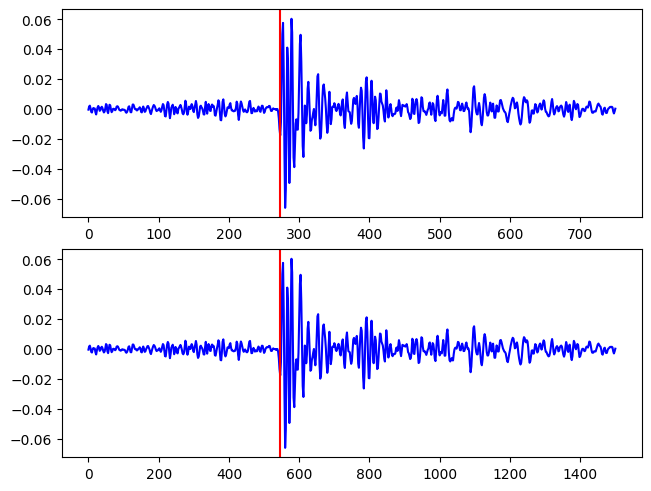

In [259]:
trace_count = 1099559
sample_i = 300
print(data_dict['SAMP_RATE'][sample_i][0])
print(data_dict['COORD_SCALE'][sample_i][0])
print(data_dict['SPARE1'][sample_i][0])
print(data_dict['data_array'][sample_i].shape[0])


sample_i = random.randrange(split_trace_receivers[x_y_ht_receiver].shape[0])
sample_count = split_trace_receivers[x_y_ht_receiver][sample_i].shape[0]

y_data = split_trace_receivers[x_y_ht_receiver][sample_i]
x_data = range(y_data.shape[0])
x_data_recalc = [i * split_sample_rate_receivers[x_y_ht_receiver][sample_i].astype(np.int32) / 1000 for i in range(y_data.shape[0])]

fig, axes = plt.subplots(2, 1, constrained_layout=True)

time_break = split_break_time_receivers[x_y_ht_receiver][sample_i]
time_break = time_break / split_sample_rate_receivers[x_y_ht_receiver][sample_i] * 1000
axes[0].plot(x_data, y_data, c='b')
axes[0].axvline(x = time_break, color = 'r', label = 'first break')

axes[1].plot(x_data_recalc, y_data, c='b')
axes[1].axvline(x = split_break_time_receivers[x_y_ht_receiver][sample_i], color = 'r', label = 'first break')

plt.show()

We successfully load data and plot trace with time breaks according to ms or mcs

## 2. Plot spectrogram

1. With windowed plt.specgram function
2. Self-wrote without windowed option

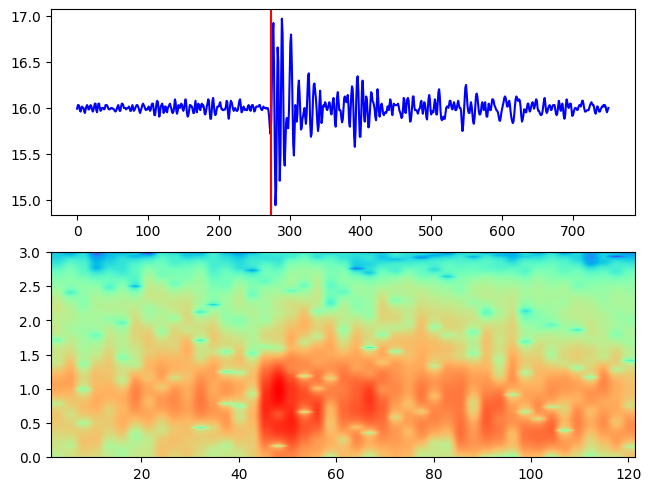

In [260]:
fig, (ax_top, ax_spec) = plt.subplots(2, 1, constrained_layout=True)

N = 32
ax_top.plot(x_data, N/2 * y_data + N/2, c='b')
ax_top.axvline(x = time_break, color = 'r', label = 'first break')
# plt.specgram(y_data, Fs=6, cmap="rainbow", NFFT=256, noverlap=128, pad_to=256*16)
Pxx, freqs, bins, cax = ax_spec.specgram(y_data, Fs=6, cmap="rainbow", NFFT=N, noverlap=16, pad_to=N*32)
plt.show()

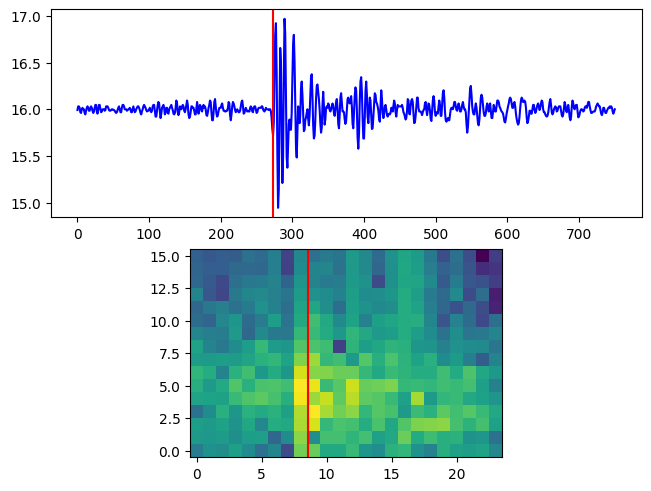

In [261]:
# Spectrogram estimation:
N = 32
S = []
for k in range(0, y_data.shape[0]+1, N):
    x = scipy.fft.fftshift(scipy.fft.fft(y_data[k:k+N], n=N))[N//2:N]
    Pxx = 10*np.log10(np.real(x*np.conj(x)))
    S.append(Pxx)
S = np.array(S)

# Frequencies:
rate = y_data.shape[0]
f = scipy.fft.fftshift(scipy.fft.fftfreq(N, d=1/rate))[N//2:N]
# array([    0. ,   187.5,   375. , ..., 23625. , 23812.5])

# Spectrogram rendering:
fig, (ax_top, ax_spec) = plt.subplots(2, 1, constrained_layout=True)
ax_top.plot(x_data, N/2 * y_data + N/2, c='b')
ax_top.axvline(x = time_break, color = 'r', label = 'first break')

ax_spec.imshow(S.T, origin='lower')
plt.axvline(x = time_break / N, color = 'r', label = 'first break')

plt.show()


## 3. Plot simple spectra in 2D

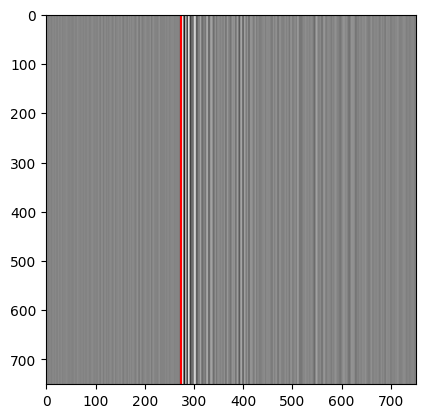

In [262]:
# Simple spectrum
xv, yv = np.meshgrid(x_data, y_data)

plt.imshow(
    np.transpose(yv),
    cmap="gray",
    # extent=[np.min(x_data), np.max(x_data), np.min(y_data), np.max(y_data)]
)
plt.axvline(x = time_break, color = 'r', label = 'first break')
#
# circle1 = plt.Circle((split_break_time_receivers[x_y_ht_receiver][sample_i], split_break_time_receivers[x_y_ht_receiver][sample_i]), 20)
# plt.gca().add_patch(circle1)
plt.show()

## 4. Plot simple spectra in 2D with Gauss approximation

We use Gauss approximation for each point of spectra according to select window. Gauss function is used according to noize VS signal differences. We suppose, than noize is more like Gaussian and will have different shapes, than signal.

In [268]:
# Define a simple function
def gauss_array(mu, std, range_N):
    x_gauss = np.linspace(int(-range_N/2), int(range_N/2), range_N)
    y_gauss = np.exp(-(x_gauss - mu)**2 / (2 * std**2)) / (std * np.sqrt(2 * np.pi))
    return y_gauss

y_data_filtered = y_data.copy()
y_data_filtered = ((y_data_filtered / np.max(np.abs(y_data_filtered))) + 1) * 127.5
y_data_filtered[y_data_filtered < np.mean(y_data)] = np.mean(y_data)

N = 32
range_gauss_N = 256
spec_data = np.zeros((range_gauss_N, y_data.shape[0]))

for idx in range(y_data_filtered.shape[0]):
    start = idx - N//2
    stop = idx + N//2
    if start < 0:
        start = 0
    if stop > y_data_filtered.shape[0]:
        stop = y_data_filtered.shape[0]
    window_sample = y_data_filtered[start:stop]
    std = np.std(window_sample.astype(np.float32))
    mu = 0  # np.mean(window_sample).astype(np.float32)
    gauss_sample = gauss_array(mu, std, range_gauss_N) * y_data_filtered[idx]
    spec_data[:, idx] = gauss_sample
print(spec_data.shape)


(256, 751)


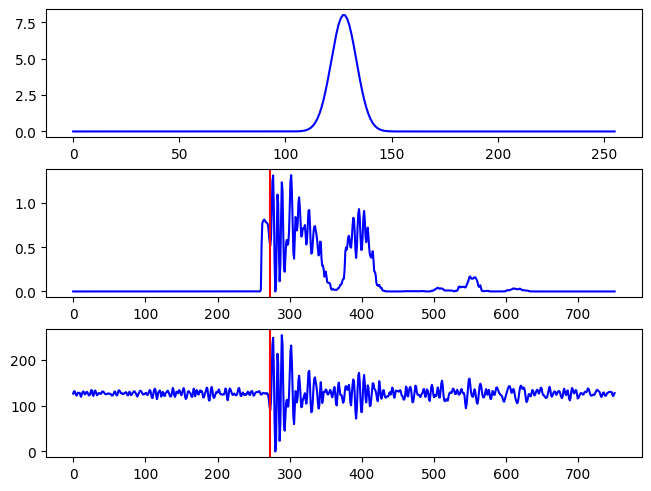

In [270]:
# fig, ax = plt.subplots(constrained_layout=True)
# In your case, use this instead:
fig, axes = plt.subplots(3, 1, constrained_layout=True)
select_i = random.randrange(spec_data.shape[0])

axes[0].plot(range(spec_data[:,select_i].shape[0]), spec_data[:,select_i], c='b')
axes[1].plot(range(spec_data[select_i, :].shape[0]), spec_data[select_i, :], c='b')
axes[1].axvline(x = time_break, color = 'r', label = 'first break')
axes[2].plot(range(y_data_filtered.shape[0]), y_data_filtered, c='b')
axes[2].axvline(x = time_break, color = 'r', label = 'first break')

plt.show()

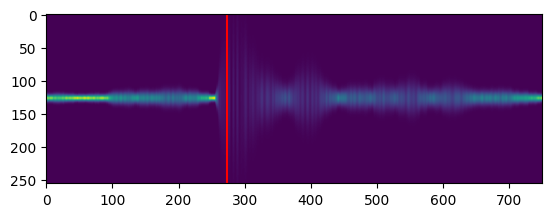

In [273]:
plt.imshow(
    spec_data,
    # cmap='hot',
    # interpolation='nearest',
    # extent=[np.min(spec_data, axis=0)[0], np.max(spec_data, axis=0)[0], np.min(spec_data, axis=1)[0], np.max(spec_data, axis=1)[0]]
)
plt.axvline(x = time_break, color = 'r', label = 'first break')
plt.show()

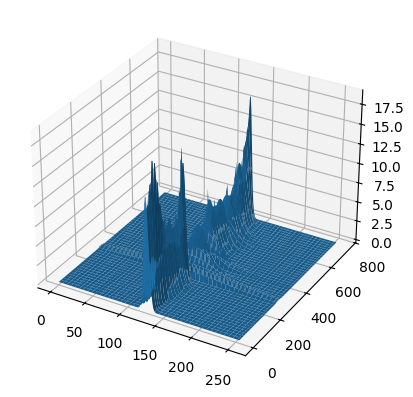

In [274]:
# Set up grid and test data
x = range(spec_data.shape[0])
y = range(spec_data.shape[1])

hf = plt.figure()
ha = hf.add_subplot(111, projection='3d')

X, Y = np.meshgrid(x, y)  # `plot_surface` expects `x` and `y` data to be 2D
ha.plot_surface(X, Y, np.transpose(spec_data))

plt.show()

## 5. Plot 2D spectrogram

According to provide task, we create 2D spectrogram with first brake highlights for each receiver.

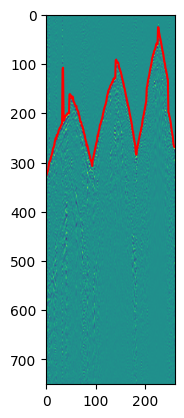

In [297]:
y_data_filtered = split_trace_receivers[x_y_ht_receiver].copy()
def my_norm(x):
    return ((x / np.max(np.abs(x))) + 1) * 127.5

y_data_filtered = np.apply_along_axis(my_norm, 1, y_data_filtered)
# y_data_filtered[y_data_filtered < np.mean(y_data)] = np.mean(y_data)

plt.imshow(np.transpose(y_data_filtered))

x_breaks = range(split_break_time_receivers[x_y_ht_receiver].shape[0])
y_breaks = []  # replace 1st brackes 0 and -1 for average between neighbors
for t_break_i, t_break in enumerate(split_break_time_receivers[x_y_ht_receiver]):
    if int(t_break) in [0, -1]:
        t_break = np.mean((
            int(split_break_time_receivers[x_y_ht_receiver][t_break_i-1]),
            int(split_break_time_receivers[x_y_ht_receiver][t_break_i+1])
        ))
    t_break = t_break / split_sample_rate_receivers[x_y_ht_receiver][t_break_i] * 1000
    y_breaks.append(t_break)
# y_data_raw = split_break_time_receivers[x_y_ht_receiver]
plt.plot(x_breaks, y_breaks, color = 'r')
plt.show()

In [300]:
round(split_trace_receivers[x_y_ht_receiver].shape[1] / split_trace_receivers[x_y_ht_receiver].shape[0], 0)

3.0

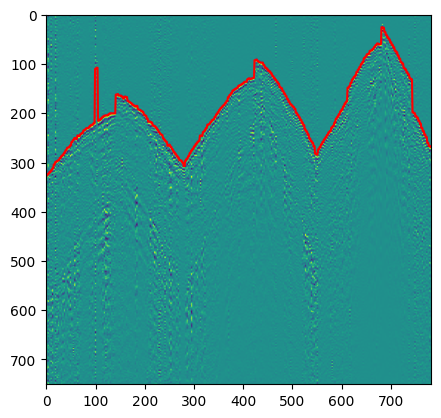

In [317]:
# Try to improve resolution
mult_const = int(round(split_trace_receivers[x_y_ht_receiver].shape[1] / split_trace_receivers[x_y_ht_receiver].shape[0], 0))
y_data_filtered = split_trace_receivers[x_y_ht_receiver].copy()
def my_norm(x):
    return ((x / np.max(np.abs(x))) + 1) * 127.5

y_data_filtered = np.apply_along_axis(my_norm, 1, y_data_filtered)
y_data_filtered = np.repeat(y_data_filtered, mult_const, axis=0)
# y_data_filtered[y_data_filtered < np.mean(y_data)] = np.mean(y_data)

plt.imshow(np.transpose(y_data_filtered))

y_breaks = []  # replace 1st brackes 0 and -1 for average between neighbors
for t_break_i, t_break in enumerate(split_break_time_receivers[x_y_ht_receiver]):
    if int(t_break) in [0, -1]:
        t_break = np.mean((
            int(split_break_time_receivers[x_y_ht_receiver][t_break_i-1]),
            int(split_break_time_receivers[x_y_ht_receiver][t_break_i+1])
        ))
    t_break = t_break / split_sample_rate_receivers[x_y_ht_receiver][t_break_i] * 1000
    y_breaks += [float(t_break)] * mult_const
# y_data_raw = split_break_time_receivers[x_y_ht_receiver]
x_breaks = range(len(y_breaks))
plt.plot(x_breaks, y_breaks, color = 'r')
plt.show()

# Create visual datasets:

Try several approaches:

1. Simple spectrogram (concatenate in 2 dimension)
2. Simple spectrogram with windowed Gauss approximation of each point in specta
3. FFT spectrogram
4. 2D seismic images for each device

## 1. Process all data

Create optimized dictionary for each data according to they devices



In [238]:


path_to_files = Path('../data')
print(list(os.walk(path_to_files))[0][-1])

['Brunswick_orig_1500ms_V2.hdf5', 'Halfmile3D_add_geom_sorted.hdf5', 'preprocessed_Sudbury3D.hdf', 'Lalor_raw_z_1500ms_norp_geom_v3.hdf5']


In [ ]:
# Plot image and mask

split_trace_receivers = {}  # x-y-ht split traces according to rec
split_break_time_receivers = {}
split_sample_rate_receivers = {}

path_to_files = Path('../data')
file_num = 0
for hdf5_file in list(os.walk(path_to_files))[0][-1]:
    if not hdf5_file.endswith('.hdf5'):
        continue
    data_dict = dict(h5py.File(path_to_file / hdf5_file)['TRACE_DATA/DEFAULT'])

    for trace_i, trace in enumerate(data_dict['data_array']):
        x_y_ht_receiver = (
            file_num,
            data_dict['REC_X'][trace_i][0].astype(np.int32),
            data_dict['REC_Y'][trace_i][0].astype(np.int32),
            data_dict['REC_HT'][trace_i][0].astype(np.int32),
        )
        trace = trace.astype(np.float16)
        if x_y_ht_receiver not in split_trace_receivers:
            split_trace_receivers[x_y_ht_receiver] = trace
            split_break_time_receivers[x_y_ht_receiver] = data_dict['SPARE1'][trace_i][0].astype(np.int16)
            split_sample_rate_receivers[x_y_ht_receiver] = data_dict['SAMP_RATE'][trace_i][0].astype(np.int16)
        else:
            split_trace_receivers[x_y_ht_receiver] = np.vstack(
                (split_trace_receivers[x_y_ht_receiver], trace)
            )
            split_break_time_receivers[x_y_ht_receiver] = np.append(
                split_break_time_receivers[x_y_ht_receiver], data_dict['SPARE1'][trace_i][0].astype(np.int16),
            )
            split_sample_rate_receivers[x_y_ht_receiver] = np.append(
                split_sample_rate_receivers[x_y_ht_receiver], data_dict['SAMP_RATE'][trace_i][0].astype(np.int16),
            )
    file_num += 1
            # split_trace_receivers[x_y_ht_receiver].append(trace)
            # split_break_time_receivers[x_y_ht_receiver].append(int(data_dict['SPARE1'][trace_i][0]))
            # split_sample_rate_receivers[x_y_ht_receiver].append(int(data_dict['SAMP_RATE'][trace_i][0]))


In [104]:
np.max(split_trace_receivers[x_y_ht_receiver][0])

np.float32(0.009609902)